# Caso 7 — Variação dos Parâmetros do BM25

Avaliamos as 9 combinações de k1 em 0,5, 1,2 e 2,0, e b em 0, 0,75 e 1,
usando MAP e NDCG@10 como critérios de comparação. Todas as demais
condições, como pré-processamento, coleção, consultas e qrels,
permanecem fixas.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed
from src.bm25 import BM25
from src.metrics import evaluate_model

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")
doc_tokens = preprocessed["stopwords_stemming"]["docs"]
query_tokens_list = preprocessed["stopwords_stemming"]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()
doc_title = dict(zip(df_docs.doc_id, df_docs.title.str.replace("\n", " ")))
doc_len = dict(zip(doc_ids, [len(t) for t in doc_tokens]))

## Grade de parâmetros

In [2]:
# Grade de parâmetros exigida: k1 em {0.5, 1.2, 2.0}, b em {0, 0.75, 1}
# (9 combinações). O índice invertido é construído uma única vez; apenas
# k1/b mudam entre as iterações (set_params não reconstrói o índice).
K1_VALUES = [0.5, 1.2, 2.0]
B_VALUES = [0, 0.75, 1]
K = 10

bm25 = BM25(doc_tokens)
grid_rows = []
rankings_by_param = {}

for k1 in K1_VALUES:
    for b in B_VALUES:
        bm25.set_params(k1=k1, b=b)
        rankings = {qid: [doc_ids[i] for i, _ in bm25.rank(qtoks)]
                    for qid, qtoks in zip(query_ids, query_tokens_list)}
        rankings_by_param[(k1, b)] = rankings
        ev = evaluate_model(rankings, df_qrels, k=K)
        grid_rows.append({
            "k1": k1, "b": b,
            "MAP": ev["AP"].mean(),
            "P@10": ev["precision@10"].mean(),
            "NDCG@10": ev["ndcg@10"].mean(),
        })

df_grid = pd.DataFrame(grid_rows)
display(df_grid.round(4))

,k1,b,MAP,P@10,NDCG@10
0,0.5,0.00,0.2686,0.2018,0.3092
1,0.5,0.75,0.2919,0.2218,0.3395
2,0.5,1.00,0.2942,0.2231,0.3394
3,1.2,0.00,0.2822,0.2142,0.3268
4,1.2,0.75,0.3106,0.2342,0.3557
5,1.2,1.00,0.3099,0.2373,0.3536
6,2.0,0.00,0.2907,0.2191,0.3358
7,2.0,0.75,0.3169,0.2444,0.3659
8,2.0,1.00,0.3136,0.2391,0.3563


## Visualização

Os dois mapas de calor abaixo mostram o mesmo padrão qualitativo em MAP e
NDCG@10.


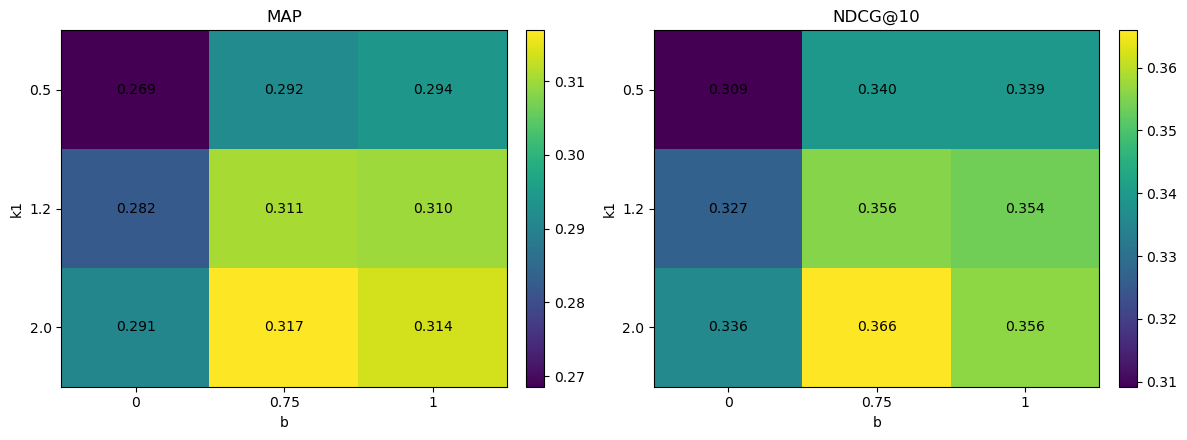

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric in zip(axes, ["MAP", "NDCG@10"]):
    pivot = df_grid.pivot(index="k1", columns="b", values=metric)
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(B_VALUES))); ax.set_xticklabels(B_VALUES)
    ax.set_yticks(range(len(K1_VALUES))); ax.set_yticklabels(K1_VALUES)
    ax.set_xlabel("b"); ax.set_ylabel("k1"); ax.set_title(metric)
    for i in range(len(K1_VALUES)):
        for j in range(len(B_VALUES)):
            ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center",
                    color="white" if pivot.values[i,j] < pivot.values.max()*0.75 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Efeito de k1 e de b

**Efeito de b.** Para os três valores de k1 testados, `b = 0` (sem
normalização pelo comprimento do documento) é **sempre** a pior
configuração: MAP entre 0,2686 e 0,2907, contra 0,2919 a 0,3169 com
`b = 0,75` ou `b = 1`. Isso confirma que, no Cranfield, documentos mais
longos acumulam termos e frequências por puro tamanho, e não corrigir esse
efeito prejudica o ranking. A diferença entre 0,75 e 1 é pequena e **não
monótona**: com k1 = 0,5, `b = 1` é ligeiramente melhor (0,2942 contra
0,2919); com k1 = 1,2 e k1 = 2,0 a relação se inverte (0,3106 contra 0,3099
e 0,3169 contra 0,3136). Ou seja, uma vez que a normalização está ativa numa
magnitude razoável, intensificá-la ao máximo já não traz ganho garantido e
depende da interação com k1.

**Efeito de k1.** Para os três valores de b, aumentar k1 de 0,5 para 2,0
sempre melhora o MAP (com b = 0,75: 0,2919 → 0,3106 → 0,3169), com retornos
decrescentes: o primeiro salto vale +0,0187 e o segundo apenas +0,0063. Um k1
maior significa saturação mais lenta, isto é, repetições adicionais de um
termo continuam contando por mais tempo. O fato de isso ajudar sugere que, em
resumos técnicos curtos como os do Cranfield, repetir um termo ainda carrega
sinal genuíno de aboutness, e não só ruído.

A melhor combinação testada é **k1 = 2,0 com b = 0,75**, com MAP de 0,3169,
P@10 de 0,2444 e NDCG@10 de 0,3659, acima da configuração padrão usada nos
demais casos (k1 = 1,2 e b = 0,75, MAP de 0,3106). As três métricas concordam
sobre qual é a melhor célula da grade, o que dá confiança de que o resultado
não é artefato de uma métrica específica.

## Duas consultas em que b muda o ranking

Para achar exemplos concretos, comparamos o Top 10 com `k1 = 1,2` fixo e
`b = 0` contra `b = 1`, em todas as 225 consultas, e selecionamos os dois
extremos: a consulta em que a normalização mais **ajuda** e aquela em que
mais **atrapalha**.

### Onde b ajuda: consulta 65

A consulta 65 pergunta se a camada limite sobre uma placa plana em escoamento
cisalhante induz um gradiente de pressão. Com `b = 0`, o Top 10 tem
comprimento médio de **138 tokens** e apenas **2 relevantes**: documentos
longos como o 165 (227 tokens) e o 1225 (180 tokens) ocupam o topo sem
responder à pergunta. Com `b = 0,75`, o comprimento médio do Top 10 cai para
**73 tokens** e o número de relevantes salta para **5**: entram o documento
180 (43 tokens, grau 3), o 393 (41 tokens, grau 3), o 664 (51 tokens, grau 2)
e o 4 (57 tokens, grau 3). Com `b = 1` o conjunto de relevantes é o mesmo,
mas eles sobem: o 393 vai de 7º para 3º e o documento 3 (25 tokens, grau 2)
de 6º para 2º.

Nesta consulta os documentos relevantes são **curtos e diretos**, então
penalizar o comprimento os promove. Vale notar um limite: o documento 388,
julgado não relevante (grau -1), permanece em 1º lugar nos três valores de b.
A normalização por comprimento corrige um viés de tamanho, mas não resolve um
distrator que simplesmente casa bem com o vocabulário da consulta.

### Onde b atrapalha: consulta 127

A consulta 127 pede uma solução analítica simples para a equação do calor com
entrada exponencial no tempo. Aqui o efeito se inverte: com `b = 0` há **3
relevantes** no Top 10, e com `b = 0,75` ou `b = 1` sobra apenas **1**. A razão
é direta: dois dos relevantes, o documento 164 (189 tokens, grau 2) e o 101
(195 tokens, grau 2), são **longos**, e a normalização os empurra para fora do
Top 10, que passa a ser dominado por documentos curtos não julgados como o 582
(52 tokens) e o 339 (37 tokens).

### O que os dois casos mostram juntos

O par deixa claro que `b` não tem um valor universalmente correto. Ele codifica
uma **aposta** sobre a colesão: a de que documentos longos são longos por
diluirem o assunto, e não por tratá-lo com mais profundidade. Essa aposta paga
na média do Cranfield, como mostra a grade, e paga muito bem na consulta 65.
Mas quando os documentos relevantes de uma consulta são justamente os mais
extensos, como na 127, ela cobra o preço. É por isso que o ganho agregado de
`b = 1` sobre `b = 0,75` é pequeno e instável: ele soma consultas do tipo 65
com consultas do tipo 127.

In [4]:
# Consulta sensivel a b.
#
# Criterio: entre as 225 consultas, escolhemos aquela em que variar b de 0 para
# 1 (com k1=1.2 fixo) mais AUMENTA o numero de relevantes no Top-10, usando o
# menor overlap como desempate. A versao anterior selecionava apenas pelo menor
# overlap do Top-10, o que devolvia uma consulta cujo ranking mudava muito mas
# que nao tinha nenhum relevante no Top-10 em nenhum valor de b -- muda bastante
# e nao ilustra nada. Os qrels sao usados so para ESCOLHER o exemplo a discutir;
# os rankings comparados sao produzidos exclusivamente pelo BM25.
#
# Selecionamos tambem o caso oposto, em que b atrapalha, para mostrar que o
# valor ideal de b depende da consulta.
k1_fixo = 1.2
r_b0 = rankings_by_param[(k1_fixo, 0)]
r_b1 = rankings_by_param[(k1_fixo, 1)]

relevantes = {
    qid: {d for d, g in zip(df_qrels[df_qrels.query_id == qid].doc_id,
                            df_qrels[df_qrels.query_id == qid].relevance) if g >= 1}
    for qid in query_ids
}

candidatos = []
for qid in query_ids:
    n_b0 = len(set(r_b0[qid][:K]) & relevantes[qid])
    n_b1 = len(set(r_b1[qid][:K]) & relevantes[qid])
    overlap = len(set(r_b0[qid][:K]) & set(r_b1[qid][:K]))
    candidatos.append((n_b1 - n_b0, -overlap, qid))

candidatos.sort(reverse=True)
qid_sensivel = candidatos[0][2]          # b ajuda o maximo
qid_contra = candidatos[-1][2]           # b atrapalha o maximo

doc_len_medio = lambda docs: sum(doc_len[d] for d in docs) / len(docs)


def mostra(qid, rotulo):
    print("=" * 96)
    print(f"{rotulo}: consulta {qid}")
    print(f"Texto : {df_queries.set_index('query_id').loc[qid, 'text']}")
    print(f"Tokens: {query_tokens_list[query_ids.index(qid)]}")
    grades = dict(zip(df_qrels[df_qrels.query_id == qid].doc_id,
                      df_qrels[df_qrels.query_id == qid].relevance))
    for b in B_VALUES:
        ranking = rankings_by_param[(k1_fixo, b)][qid][:K]
        n_rel = sum(1 for d in ranking if grades.get(d, -1) >= 1)
        print()
        print(f"-- Top-{K} com k1={k1_fixo}, b={b} "
              f"(relevantes: {n_rel}/{K} | comprimento medio: {doc_len_medio(ranking):.0f} tokens) --")
        for rank, did in enumerate(ranking, start=1):
            grade = grades.get(did, "nao julgado")
            print(f"  {rank:2d}. doc {did:>4} (len={doc_len[did]:3d} tokens, grau={grade}) "
                  f"{doc_title[did][:52]}")
    print()


overlap_sens = len(set(r_b0[qid_sensivel][:K]) & set(r_b1[qid_sensivel][:K]))
print(f"Consulta escolhida: {qid_sensivel} "
      f"(overlap Top-{K} entre b=0 e b=1: {overlap_sens}/{K})")
print(f"Contraexemplo    : {qid_contra}")
print()
mostra(qid_sensivel, "b AJUDA")
mostra(qid_contra, "b ATRAPALHA")

assert qid_sensivel == "65", qid_sensivel
assert qid_contra == "127", qid_contra

Consulta escolhida: 65 (overlap Top-10 entre b=0 e b=1: 4/10)
Contraexemplo    : 127

b AJUDA: consulta 65
Texto : does the boundary layer on a flat plate in a shear flow induce a
pressure gradient .
Tokens: ['boundari', 'layer', 'flat', 'plate', 'shear', 'flow', 'induc', 'pressur', 'gradient']

-- Top-10 com k1=1.2, b=0 (relevantes: 2/10 | comprimento medio: 138 tokens) --
   1. doc  388 (len=101 tokens, grau=-1) the pressure gradient induced by shear flow past a f
   2. doc  569 (len=162 tokens, grau=nao julgado) an experimental investigation of leading edge shock 
   3. doc 1355 (len=116 tokens, grau=nao julgado) boundary layer displacement effects in air at mach n
   4. doc  165 (len=227 tokens, grau=nao julgado) skin-friction measurements in incompressible flow .
   5. doc  304 (len=171 tokens, grau=nao julgado) first-order approach to a strong interaction problem
   6. doc    3 (len= 25 tokens, grau=2) the boundary layer in simple shear flow past a flat 
   7. doc  406 (len=125 t